In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('insurance.csv')

In [42]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [43]:
df.shape

(1338, 7)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [45]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [46]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(1)

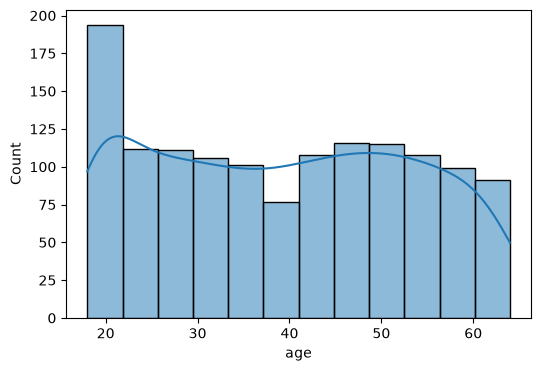

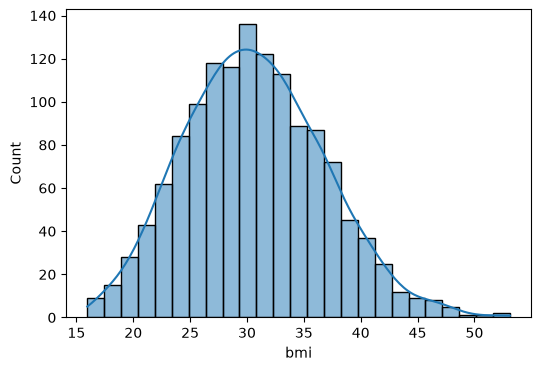

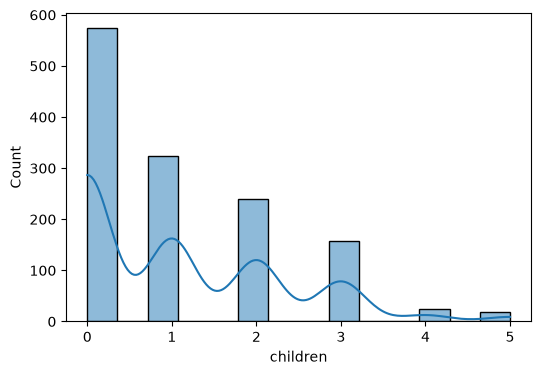

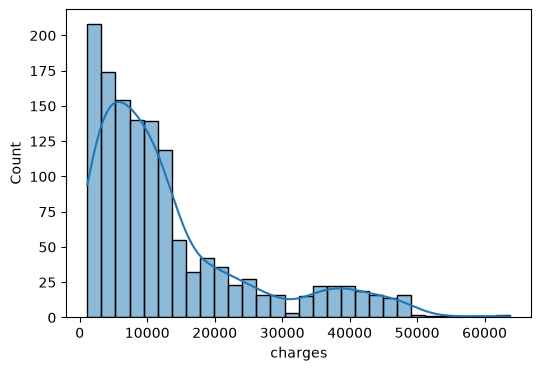

In [48]:
numeric_column = ['age','bmi','children','charges']
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)

In [49]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

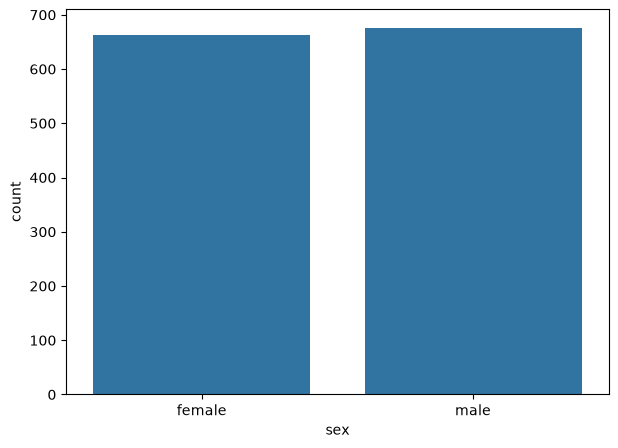

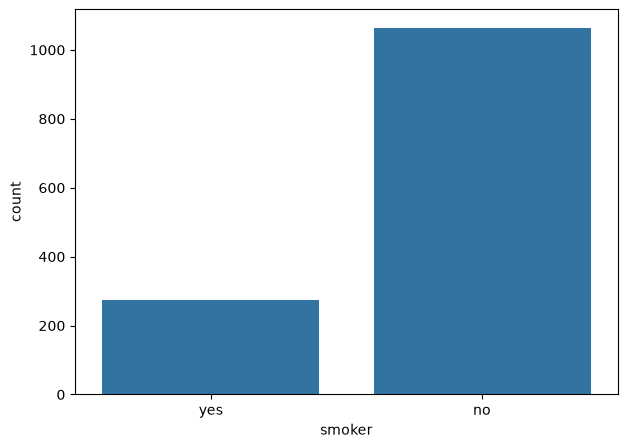

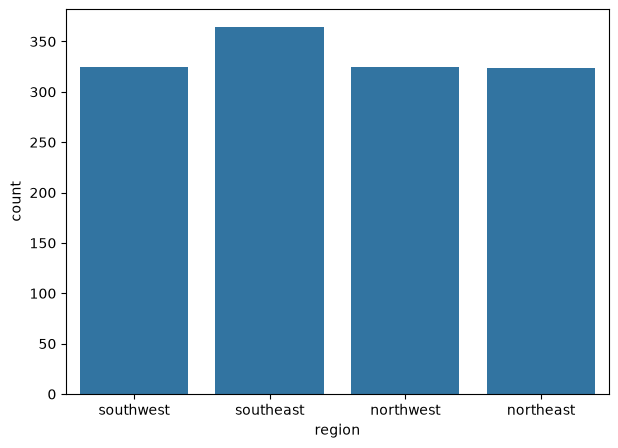

In [50]:
categorical_columns = ['sex','smoker','region']
for col in categorical_columns:
    plt.figure(figsize=(7,5))
    sns.countplot(x=df[col])

<Axes: xlabel='age', ylabel='charges'>

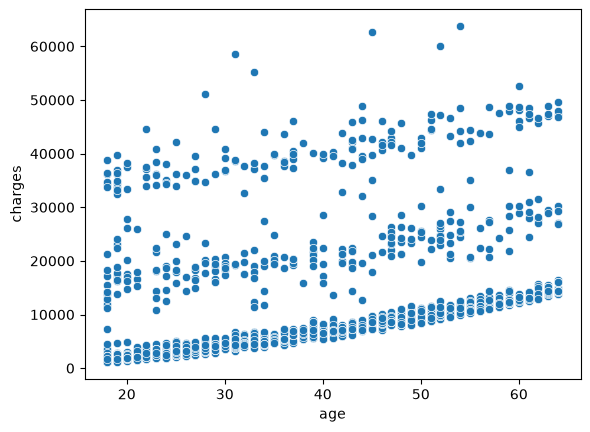

In [51]:
sns.scatterplot(x=df['age'],y=df['charges'])

<Axes: xlabel='charges', ylabel='smoker'>

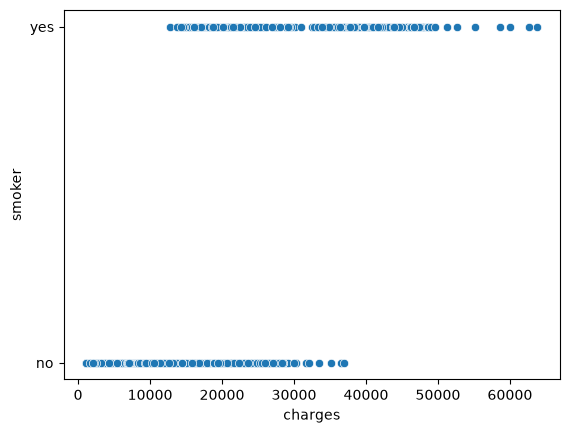

In [52]:
sns.scatterplot(y=df['smoker'],x=df['charges'])

<Axes: >

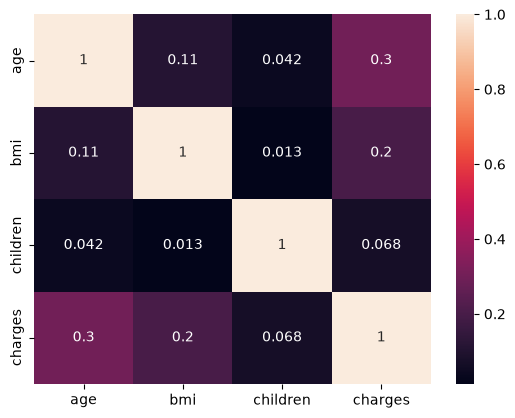

In [53]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [54]:
df['is_smoker'] = df['smoker'].map({
    'no' : 0,
    'yes' : 1
})

In [55]:
df

,age,sex,bmi,children,smoker,region,charges,is_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


<Axes: >

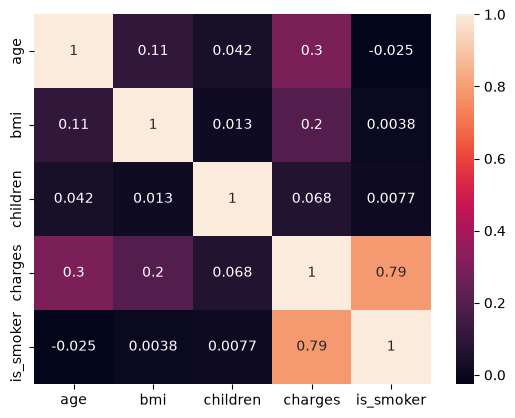

In [56]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [57]:
df['sex_encoded'] = df['sex'].map({
    'female' : 0,
    'male' : 1
})

<Axes: >

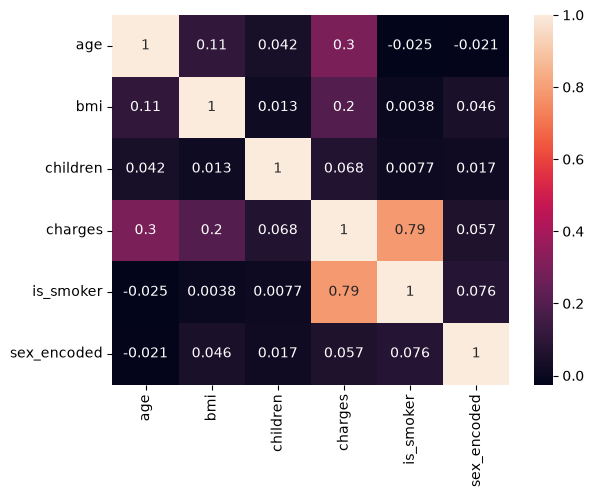

In [58]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [59]:
df.drop(columns='sex_encoded',inplace=True)

<Axes: xlabel='smoker', ylabel='charges'>

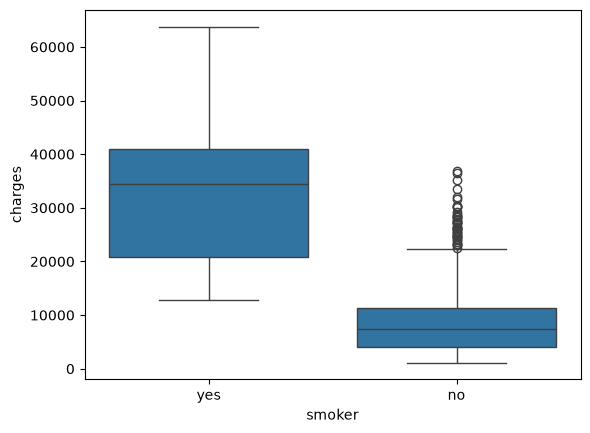

In [60]:
sns.boxplot(x='smoker',y='charges',data=df)

<Axes: xlabel='charges', ylabel='region'>

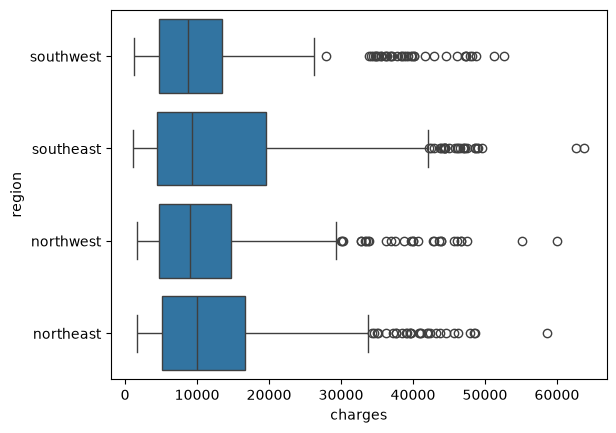

In [61]:
sns.boxplot(x='charges',y='region',data=df)

<Axes: xlabel='sex', ylabel='charges'>

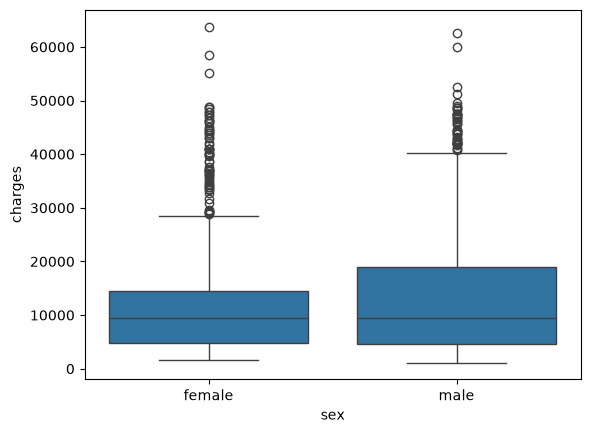

In [62]:
sns.boxplot(x='sex',y='charges',data=df)

<Axes: xlabel='age', ylabel='charges'>

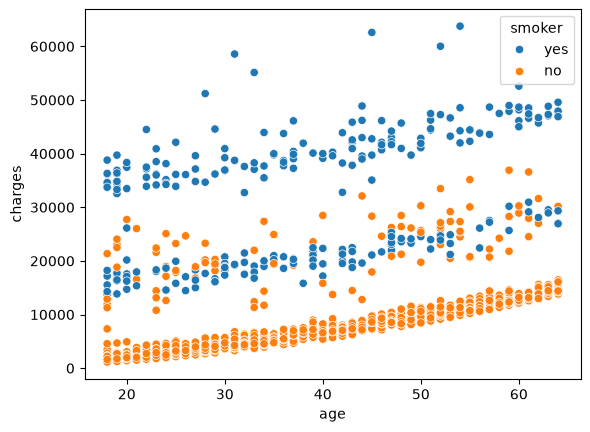

In [63]:
sns.scatterplot(x='age',y='charges',data=df,hue='smoker')

<Axes: xlabel='bmi', ylabel='charges'>

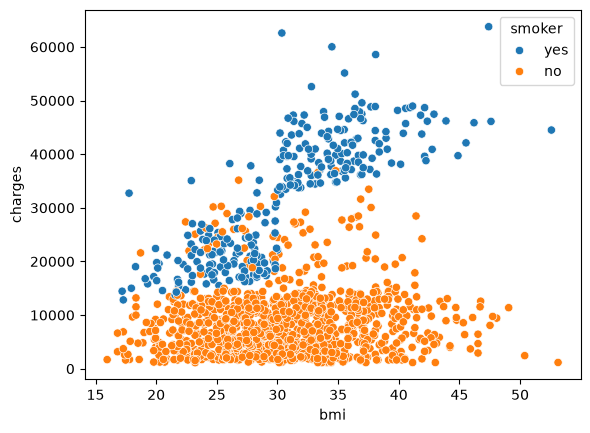

In [64]:
sns.scatterplot(data=df,x='bmi',y='charges',hue='smoker')

<Axes: xlabel='age', ylabel='charges'>

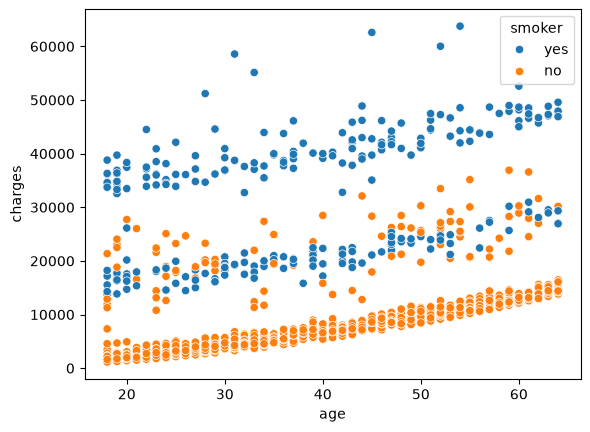

In [65]:
sns.scatterplot(data=df,x='age',y='charges',hue='smoker')

In [66]:
df.head()

,age,sex,bmi,children,smoker,region,charges,is_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [67]:
df.drop(columns='is_smoker',inplace=True)

In [68]:
df['sex'] = df['sex'].map({
    'male' : 0,
    'female' : 1
})
df['smoker'] = df['smoker'].map({
    'no' : 0,
    'yes' : 1
})

In [69]:
from sklearn.preprocessing import StandardScaler
columns  = ['age','bmi','children']
scaler = StandardScaler()
df[columns] = scaler.fit_transform(df[columns])

In [70]:
df

,age,sex,bmi,children,smoker,region,charges
0,-1.438764,1,-0.453320,-0.908614,1,southwest,16884.92400
1,-1.509965,0,0.509621,-0.078767,0,southeast,1725.55230
2,-0.797954,0,0.383307,1.580926,0,southeast,4449.46200
3,-0.441948,0,-1.305531,-0.908614,0,northwest,21984.47061
4,-0.513149,0,-0.292556,-0.908614,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,0.768473,0,0.050297,1.580926,0,northwest,10600.54830
1334,-1.509965,1,0.206139,-0.908614,0,northeast,2205.98080
1335,-1.509965,1,1.014878,-0.908614,0,southeast,1629.83350
1336,-1.296362,1,-0.797813,-0.908614,0,southwest,2007.94500


In [71]:
df = pd.get_dummies(df,columns=['region'],drop_first=True,dtype=int)

In [72]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.438764,1,-0.453320,-0.908614,1,16884.92400,0,0,1
1,-1.509965,0,0.509621,-0.078767,0,1725.55230,0,1,0
2,-0.797954,0,0.383307,1.580926,0,4449.46200,0,1,0
3,-0.441948,0,-1.305531,-0.908614,0,21984.47061,1,0,0
4,-0.513149,0,-0.292556,-0.908614,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,0.768473,0,0.050297,1.580926,0,10600.54830,1,0,0
1334,-1.509965,1,0.206139,-0.908614,0,2205.98080,0,0,0
1335,-1.509965,1,1.014878,-0.908614,0,1629.83350,0,1,0
1336,-1.296362,1,-0.797813,-0.908614,0,2007.94500,0,0,1


In [74]:
x = df.drop('charges',axis=1)
y = df['charges']

In [75]:
x.dtypes

age                 float64
sex                   int64
bmi                 float64
children            float64
smoker                int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

In [82]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [83]:
X_train.shape,y_train.shape

((1070, 8), (1070,))

    Scaling should be done at this stage not before this 

In [84]:
scaler = StandardScaler()
X_train[['age','bmi','children']] = scaler.fit_transform(
    X_train[['age','bmi','children']]
)
X_test[['age','bmi','children']] = scaler.fit_transform(
    X_test[['age','bmi','children']]
)

In [85]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3614.98, 18.59,2036.23,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','sex','bmi',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8937
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [86]:
y_pred = lr.predict(X_test)

In [90]:
print(y_pred[:5])
print(y_test[:5].values)

[ 9129.949559    7101.95963531 37001.30727948  9629.4907709
 26939.83796064]
[ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918 ]


In [91]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)

In [92]:
print(mae)

4167.87054784539


In [93]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

0.7836640670391223


In [94]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

5795.332533018758


In [95]:
lr.coef_

array([ 3.61497541e+03,  1.85916916e+01,  2.03622812e+03,  5.16890247e+02,
        2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02])

In [96]:
lr.intercept_

np.float64(8936.653109861873)